### 이미지 감지 후 결과 출력

In [30]:
!pip install ultralytics opencv-python

In [31]:
import cv2
from ultralytics import YOLO
import numpy as np
import matplotlib.pyplot as plt
import os

model = YOLO('yolo11n.pt')

In [32]:
image_path = '/content/drive/MyDrive/yolo_imgs/image1.jpg'
image = cv2.imread(image_path)

if image is None:
  print('이미지를 읽을 수 없어요')
  exit()

results = model(image) # 여기서부터 감지가 시작됨
print(results)


0: 416x640 2 persons, 325.9ms
Speed: 5.9ms preprocess, 325.9ms inference, 12.2ms postprocess per image at shape (1, 3, 416, 640)
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange

감지된 사람 수는 2명


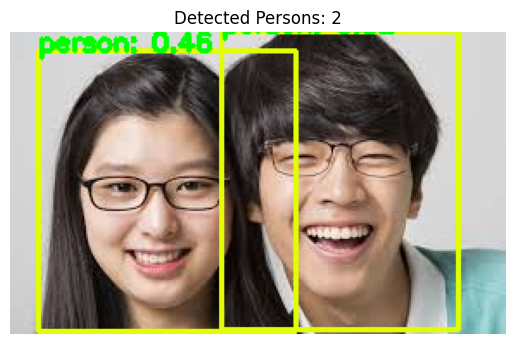

감지된 결과 yolo3output.jpg로 저장 성공


In [33]:
# 원본 이미지 별도 기억
original = image.copy()

person_count = 0

for result in results:
  for box in result.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0]) # 죄표 반환
    label = result.names[int(box.cls[0])] # class이름 반환
    confidence = box.conf[0].item() # 신뢰도 반환

    if label.lower() == 'person':
      person_count += 1

    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 225), 2)
    cv2.putText(image, f'{label}: {confidence:.2f}', (x1, y1), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
print(f'감지된 사람 수는 {person_count}명')

# 시각화
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'Detected Persons: {person_count}')
plt.show()

# 바운딩 박스 결과를 이미지로 저장
output_path = 'yolo3output.jpg'
cv2.imwrite(output_path, image)
print(f'감지된 결과 {output_path}로 저장 성공')

In [34]:
# 바운딩 박스 좌표 출력하기
for result in results:
  for box in result.boxes:
    label = result.names[int(box.cls[0])]
    confidence = box.conf[0].item()
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    print(f'라벨:{label}, 신뢰도:{confidence}, 좌표:({x1},{y1}),({x2},{y2})')

라벨:person, 신뢰도:0.8158668279647827, 좌표:(122,0),(259,172)
라벨:person, 신뢰도:0.46297913789749146, 좌표:(16,11),(165,173)


In [35]:
# 신뢰도 높은 객체만 필터링(예:70% 이상)
for idx, result in enumerate(results):
  print(f'전체 라벨 순서중 이미지 {idx}번째 결과 : ')

  # 이미지 객체가 감지 되었는지 안되었는지 판단하는 변수 선언
  found = False

  for box in result.boxes:
    label = result.names[int(box.cls[0])]
    confidence = box.conf[0].item()
    x1, y1, x2, y2 = map(int, box.xyxy[0])

    if confidence >= 0.2:
      print(f'    - {label} {confidence:.2f}')
      found = True
  if not found:
    print('   - 신뢰도 70% 이상 객체가 없어요')


전체 라벨 순서중 이미지 0번째 결과 : 
    - person 0.82
    - person 0.46


In [39]:
# 바운딩 박스 내부 객체 저장1
for idx, result in enumerate(results):
  for j , box in enumerate(result.boxes):
    label = result.names[int(box.cls[0])]
    confidence = box.conf[0].item()
    x1, y1, x2, y2 = map(int, box.xyxy[0])

    # 이미지에서 ROI(Regine Of Interest : 관심영역) 추출
    # 배열 슬라이싱 (행방향, 열방향 으로 자르기) 새로운 이미지 배열을 만듦
    cropped = image[y1:y2, x1:x2]

    # 저장 파일 만들기
    crop_path = f'crop_{idx}_{j}_{label}_{confidence:.2f}.jpg'
    cv2.imwrite(crop_path, cropped)
    print(f'  -> 객체 {label} 저장 성공 {crop_path}')

  -> 객체 person 저장 성공 crop_0_0_person_0.82.jpg
  -> 객체 person 저장 성공 crop_0_1_person_0.46.jpg


In [45]:
# 바운딩 박스 내부 객체 저장2 -> 바운딩 박스 없이 이미지만 저장
os.makedirs('crops', exist_ok=True)

for idx, result in enumerate(results):
  for j , box in enumerate(result.boxes):
    label = result.names[int(box.cls[0])]
    confidence = box.conf[0].item()
    x1, y1, x2, y2 = map(int, box.xyxy[0])

    # 이미지에서 ROI(Regine Of Interest : 관심영역) 추출
    # 배열 슬라이싱 (행방향, 열방향 으로 자르기) 새로운 이미지 배열을 만듦
    cropped = original[y1:y2, x1:x2]

    # 저장 파일 만들기
    crop_path = os.path.join('crops', f'crop_{idx}_{j}_{label}_{confidence:.2f}.jpg')
    cv2.imwrite(crop_path, cropped)
    print(f'  -> 객체 {label} 저장(바운딩박스x) 성공 {crop_path}')

  -> 객체 person 저장(바운딩박스x) 성공 crops/crop_0_0_person_0.82.jpg
  -> 객체 person 저장(바운딩박스x) 성공 crops/crop_0_1_person_0.46.jpg


person => 1의 중심좌표 = (190,86), 신뢰도:0.82
person => 2의 중심좌표 = (90,92), 신뢰도:0.46


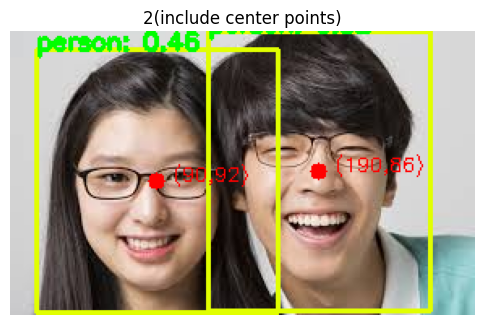

In [49]:
# 감지된 객체 중심 좌표 출력 + 시각화
person_count = 0

for result in results:
  for box in result.boxes:
    label = result.names[int(box.cls[0])]
    confidence = box.conf[0].item()
    x1, y1, x2, y2 = map(int, box.xyxy[0])

    # 중심좌표 구하기
    center_x = (x1 + x2) // 2
    center_y = (y1 + y2) // 2

    if label.lower() == 'person':
      person_count += 1
      print(f'person => {person_count}의 중심좌표 = ({center_x},{center_y}), 신뢰도:{confidence:.2f}')

      # 중심 원 그리기
      cv2.circle(image, (center_x, center_y), 5, (0, 0, 255), -1)

      coord_text=f'({center_x},{center_y})'
      cv2.putText(image, coord_text, (center_x + 10, center_y), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)

    # 바운딩 박스 출력
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 225), 2)
    cv2.putText(image, f'{label}: {confidence:.2f}', (x1, y1), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

plt.figure(figsize=(6, 5))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'{person_count}(include center points)')
plt.show()


0: 640x640 2 persons, 635.5ms
1: 640x640 3 persons, 1 handbag, 635.5ms
Speed: 17.8ms preprocess, 635.5ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)

이미지 0 번째 (/content/drive/MyDrive/yolo_imgs/image1.jpg) 결과 :
  -person (0.78)
  -person (0.43)

이미지 1 번째 (/content/drive/MyDrive/yolo_imgs/image2.jpg) 결과 :
  -person (0.83)
  -person (0.73)
  -handbag (0.45)


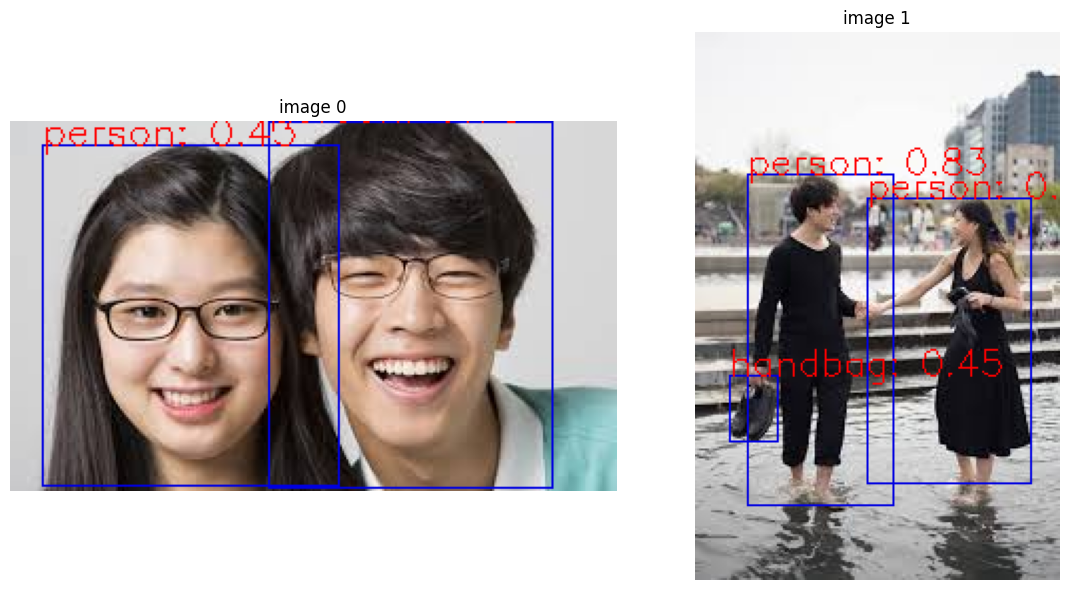

In [54]:
# 복수 이미지 처리
image_paths = ['/content/drive/MyDrive/yolo_imgs/image1.jpg', '/content/drive/MyDrive/yolo_imgs/image2.jpg']
results = model(image_paths)

# 시각화
fig, axes = plt.subplots(1, len(image_paths), figsize=(12, 6))

for idx, (result, image_path) in enumerate(zip(results, image_paths)):
  print(f'\n이미지 {idx} 번째 ({image_path}) 결과 :')
  found = False

  # 원본 이미지 읽기
  image = cv2.imread(image_path)
  image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

  for box in result.boxes:
    label = model.names[int(box.cls[0])]
    confidence = box.conf[0].item()

    if confidence >= 0.4:
      print(f'  -{label} ({confidence:.2f})')
      found = True

      x1, y1, x2, y2 = map(int, box.xyxy[0])
      # 바운딩 박스 출력
      cv2.rectangle(image, (x1, y1), (x2, y2), (0, 0, 225), 1)
      cv2.putText(image, f'{label}: {confidence:.2f}', (x1, y1), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 1)

  if not found:
    print('신뢰도 40%이상 감지된 객체가 없습니다.')

  axes[idx].imshow(image)
  axes[idx].set_title(f"image {idx}")
  axes[idx].axis('off')

plt.tight_layout()
plt.show()